In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:

url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/employee_attrition/HR-Employee-Attrition-All.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

In [5]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()
print("After cleaning — Shape:", df.shape)

# Convert Attrition column to 0/1 (this dataset has Yes/No)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("\nColumns:", df.columns.tolist())
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())

Duplicate rows: 0
After cleaning — Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition value counts:
Attrition
0    1233
1     237
Name: count, dtype: int64


Attrition Rate:
 Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


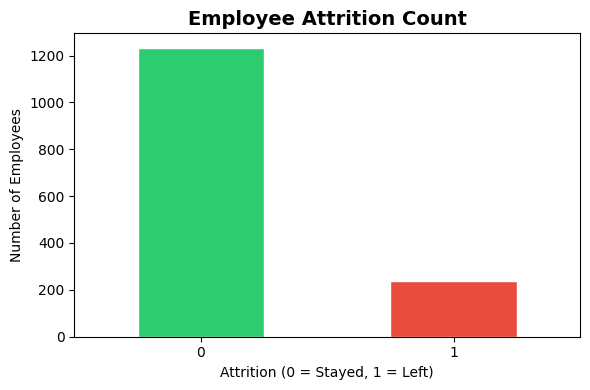

Insight: ~16% of employees left the company.


In [6]:
# Overall attrition rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:\n", attrition_rate.round(2))

# Plot
plt.figure(figsize=(6,4))
colors = ['#2ecc71', '#e74c3c']
df['Attrition'].value_counts().plot(
    kind='bar', color=colors, edgecolor='white', width=0.5
)
plt.title('Employee Attrition Count', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('attrition_overview.png', dpi=150)
plt.show()
print("Insight: ~16% of employees left the company.")

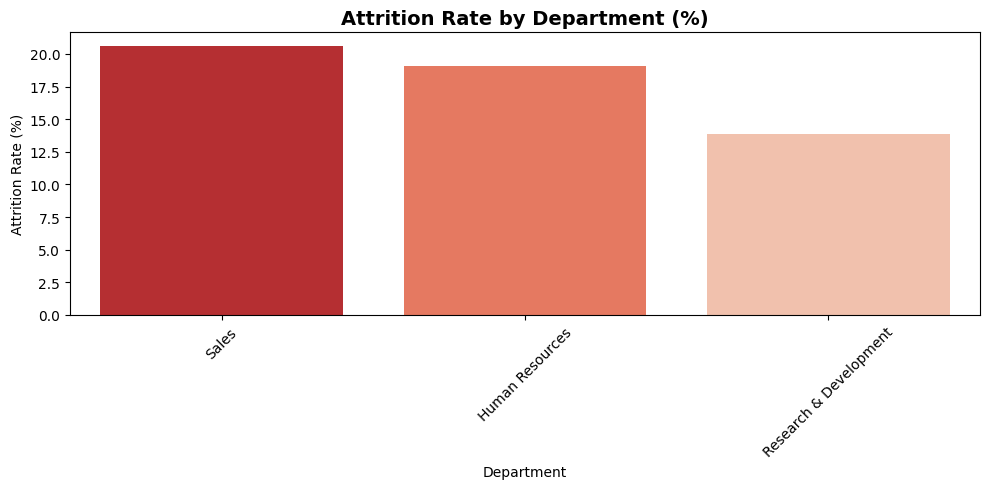

Insight: Sales department has the highest attrition rate.


In [7]:
plt.figure(figsize=(10,5))
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)

sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')
plt.title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dept_attrition.png', dpi=150)
plt.show()
print("Insight: Sales department has the highest attrition rate.")

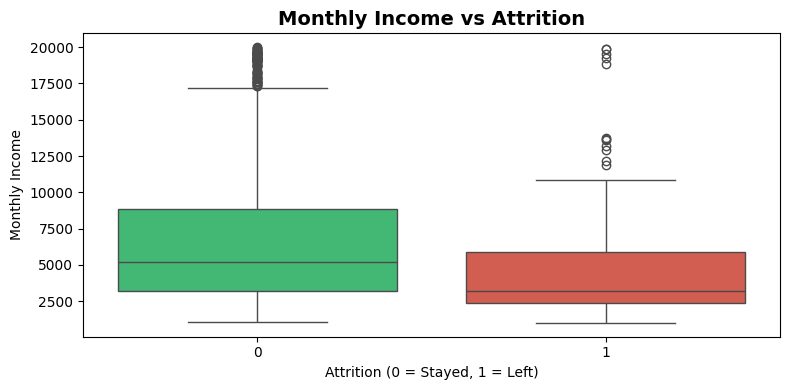

Insight: Employees who left had significantly lower monthly income.


In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    palette={'0':'#2ecc71', '1':'#e74c3c'}
)
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('income_attrition.png', dpi=150)
plt.show()
print("Insight: Employees who left had significantly lower monthly income.")

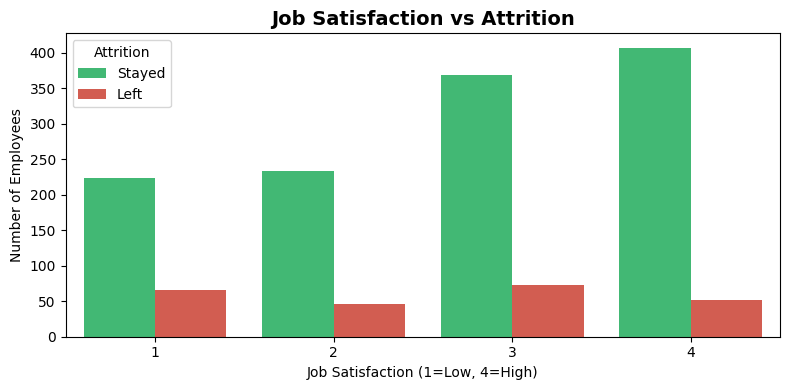

Insight: Employees with low job satisfaction (1) leave at the highest rate.


In [11]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='JobSatisfaction',
    hue='Attrition',
    palette={0:'#2ecc71', 1:'#e74c3c'}
)
plt.title('Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Stayed','Left'])
plt.tight_layout()
plt.savefig('satisfaction_attrition.png', dpi=150)
plt.show()
print("Insight: Employees with low job satisfaction (1) leave at the highest rate.")

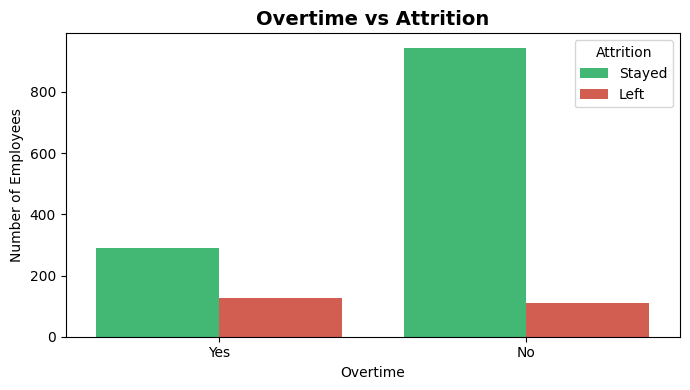

Insight: Employees working overtime are far more likely to leave.


In [12]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition',
    palette={0:'#2ecc71', 1:'#e74c3c'}
)
plt.title('Overtime vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Stayed','Left'])
plt.tight_layout()
plt.savefig('overtime_attrition.png', dpi=150)
plt.show()
print("Insight: Employees working overtime are far more likely to leave.")

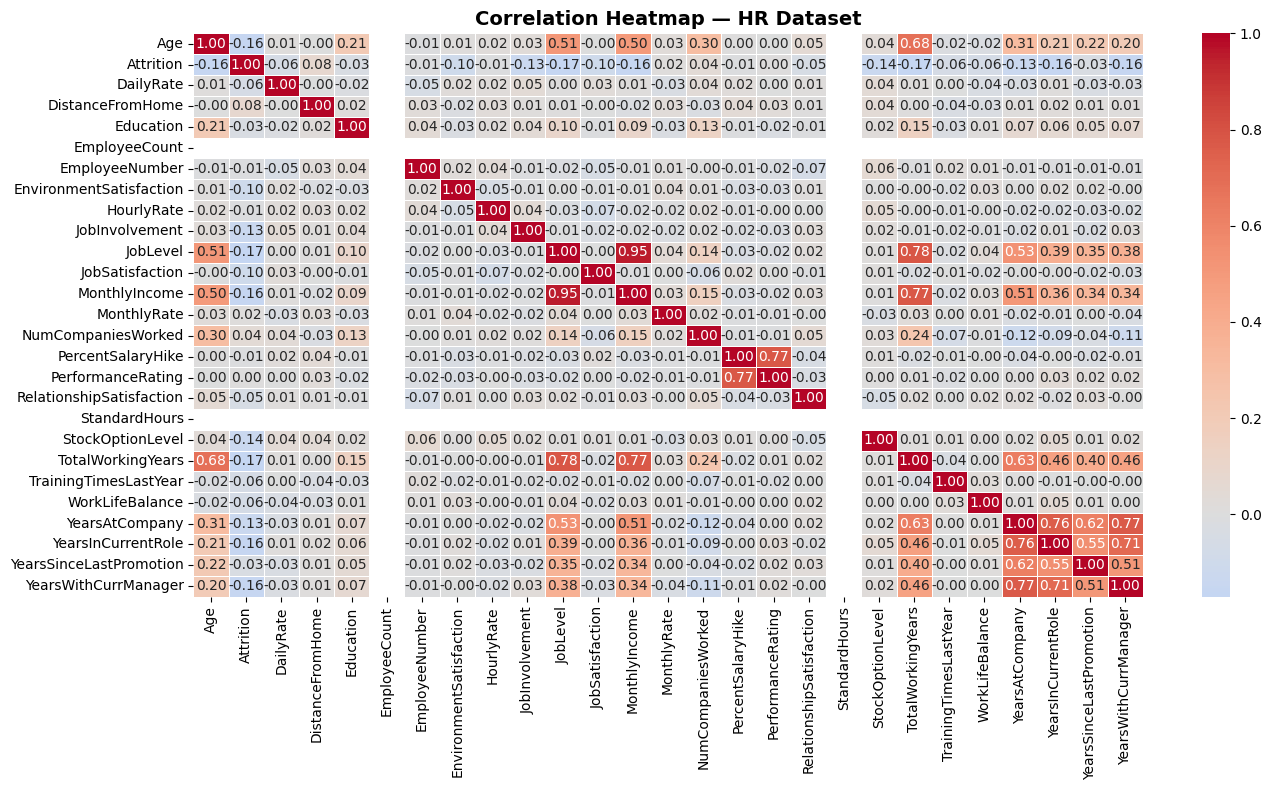

Insight: Monthly income and job level have the strongest negative correlation with attrition.


In [13]:
plt.figure(figsize=(14,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    center=0
)
plt.title('Correlation Heatmap — HR Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Insight: Monthly income and job level have the strongest negative correlation with attrition.")

In [14]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         HR ATTRITION ANALYSIS — KEY FINDINGS                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset  : IBM HR Analytics — 1,470 employees, 35 columns  ║
║                                                              ║
║  1. Overall attrition rate    : ~16%                         ║
║  2. Highest attrition dept    : Sales                        ║
║  3. Income impact             : Leavers earn significantly   ║
║                                 less than those who stayed   ║
║  4. Job satisfaction          : Low satisfaction = high risk ║
║  5. Overtime                  : Overtime employees leave     ║
║                                 at almost double the rate    ║
║                                                              ║
║  BUSINESS RECOMMENDATION:                                    ║
║  Prioritise salary review and workload balance for Sales     ║
║  team employees with JobSatisfaction score of 1 or 2        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         HR ATTRITION ANALYSIS — KEY FINDINGS                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset  : IBM HR Analytics — 1,470 employees, 35 columns  ║
║                                                              ║
║  1. Overall attrition rate    : ~16%                         ║
║  2. Highest attrition dept    : Sales                        ║
║  3. Income impact             : Leavers earn significantly   ║
║                                 less than those who stayed   ║
║  4. Job satisfaction          : Low satisfaction = high risk ║
║  5. Overtime                  : Overtime employees leave     ║
║                                 at almost double the rate    ║
║                                                              ║
║  BUSINESS RECOMMENDATION:                                    ║
║  Prioritise salary revie